<a href="https://colab.research.google.com/github/WahyuKhairi06/JaringanSyarafTiruan_WahyuKhairi_2311531009/blob/main/JST_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install -q torch torchvision scikit-learn matplotlib

import os, zipfile, random, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models


from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [14]:
ZIP_DATASET = "/content/drive/MyDrive/dataset/trash_image.zip"
EXTRACT_PATH = "/content/data_trash/"

os.makedirs(EXTRACT_PATH, exist_ok=True)

# Extract ZIP (skip jika sudah ada)
if not os.listdir(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_DATASET, 'r') as zf:
        zf.extractall(EXTRACT_PATH)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

# Detect root folder (folder berisi subfolder kelas)
def find_root(path):
    items = [p for p in Path(path).iterdir() if p.is_dir()]
    for d in items:
        if any(f.suffix.lower() in ['.jpg','.jpeg','.png'] for f in d.iterdir()):
            return path
    return str(items[0])

DATA_ROOT = find_root(EXTRACT_PATH)
print("DATA ROOT:", DATA_ROOT)


Dataset already extracted.
DATA ROOT: /content/data_trash/


In [15]:
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # augmentasi tambahan (mencegah overfitting)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.RandomAffine(0, translate=(0.05, 0.05)),

    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2)
])


val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])


In [16]:
full_ds = datasets.ImageFolder(DATA_ROOT, transform=train_tf)
class_names = full_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# Split dataset
train_size = int(0.7 * len(full_ds))
val_size = int(0.15 * len(full_ds))
test_size = len(full_ds) - train_size - val_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(full_ds, [train_size, val_size, test_size])


# Get labels for the training subset using its indices into the full dataset
train_labels = [full_ds.targets[i] for i in train_ds.indices]

# Hitung jumlah gambar per kelas untuk train_ds
train_class_counts = np.bincount(train_labels, minlength=num_classes)
print("Jumlah per kelas (Train Set):", train_class_counts)


# Re-initialize DataLoader with the corrected sampler
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Jumlah per kelas (Train Set): [275 367 283 427 323  93]


In [20]:
# Load ResNet50 pretrained
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 1) Freeze seluruh backbone (warm-up)
for param in model.parameters():
    param.requires_grad = False

# 2) Ganti FC layer
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, num_classes)
)

# hanya FC yang trainable
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# LOSS — tetap pakai label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# 3) Optimizer untuk warm-up
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4,
    weight_decay=1e-4
)

# Scheduler tetap
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)



In [21]:
EPOCHS = 10
best_acc = 0
patience = 5
wait = 0

train_losses = []; val_losses = []
train_accs = []; val_accs = []

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0; train_loss_sum = 0

    # ---------------- Training ----------------
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        # anti overfitting (grad clipping)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        optimizer.step()

        train_loss_sum += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)

    # ---------------- Validation ----------------
    model.eval()
    val_correct = 0; val_loss_sum = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    scheduler.step(val_loss)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # ================================================================
    #   UNFREEZE LAYER4 SAAT MASUK EPOCH 3 (0,1,2 warm-up → 3 fine-tune)
    # ================================================================
    if epoch == 2:
        print("Unfreezing layer4 → mulai fine-tuning...")
        for param in model.layer4.parameters():
            param.requires_grad = True

        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=5e-5, weight_decay=1e-4
        )

        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=2, factor=0.5
        )

    # ---------------- Early Stopping ----------------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50.pth")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("EARLY STOPPING TRIGGERED.")
            break


Epoch 1/10 | Train Acc: 0.3207 | Val Acc: 0.5040
Epoch 2/10 | Train Acc: 0.4955 | Val Acc: 0.6649
Epoch 3/10 | Train Acc: 0.5854 | Val Acc: 0.6412
Unfreezing layer4 → mulai fine-tuning...
Epoch 4/10 | Train Acc: 0.7217 | Val Acc: 0.8179
Epoch 5/10 | Train Acc: 0.8258 | Val Acc: 0.8391
Epoch 6/10 | Train Acc: 0.8727 | Val Acc: 0.8813
Epoch 7/10 | Train Acc: 0.9078 | Val Acc: 0.8997
Epoch 8/10 | Train Acc: 0.9344 | Val Acc: 0.9024
Epoch 9/10 | Train Acc: 0.9400 | Val Acc: 0.8892
Epoch 10/10 | Train Acc: 0.9491 | Val Acc: 0.8945


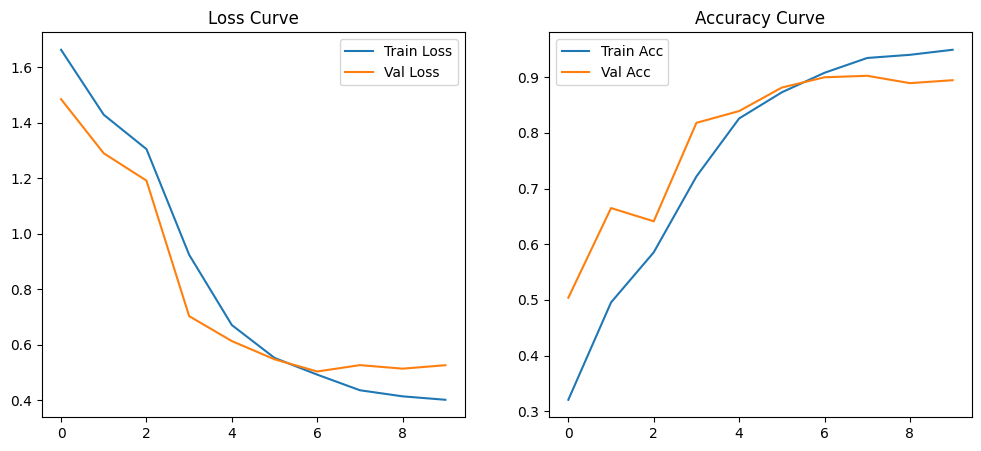

In [22]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend(); plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend(); plt.title("Accuracy Curve")

plt.show()


In [76]:
print("\n--- Numerical Loss Values (Final 10-Epoch Training) ---\n")
print("Final Training Loss per Epoch:")
for i, loss in enumerate(train_losses):
    print(f"- Epoch {i+1}: {loss:.2f}")

print("\nFinal Validation Loss per Epoch:")
for i, loss in enumerate(val_losses):
    print(f"- Epoch {i+1}: {loss:.2f}")


--- Numerical Loss Values (Final 10-Epoch Training) ---

Final Training Loss per Epoch:
- Epoch 1: 1.66
- Epoch 2: 1.43
- Epoch 3: 1.31
- Epoch 4: 0.92
- Epoch 5: 0.67
- Epoch 6: 0.55
- Epoch 7: 0.49
- Epoch 8: 0.44
- Epoch 9: 0.41
- Epoch 10: 0.40

Final Validation Loss per Epoch:
- Epoch 1: 1.49
- Epoch 2: 1.29
- Epoch 3: 1.19
- Epoch 4: 0.70
- Epoch 5: 0.61
- Epoch 6: 0.55
- Epoch 7: 0.50
- Epoch 8: 0.53
- Epoch 9: 0.51
- Epoch 10: 0.53



Test Accuracy: 86.84%

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.96      0.85      0.90        60
       glass       0.83      0.90      0.86        63
       metal       0.83      0.94      0.88        64
       paper       0.85      0.93      0.89        83
     plastic       0.91      0.82      0.86        87
       trash       0.82      0.61      0.70        23

    accuracy                           0.87       380
   macro avg       0.87      0.84      0.85       380
weighted avg       0.87      0.87      0.87       380



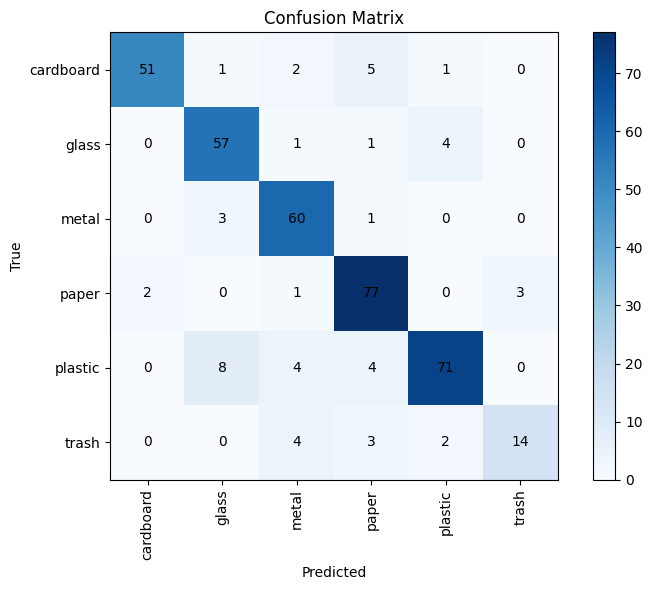

In [28]:
model.load_state_dict(torch.load("best_resnet50.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")

print("\nClassification Report:")

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

# Tampilkan angka di setiap kotak
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
from copy import deepcopy

def train_one_experiment(model, optimizer, criterion, scheduler, epochs=10):
    """Melatih satu eksperimen dan mengembalikan val_acc terbaik"""
    best_acc = 0
    wait = 0
    patience = 3

    for epoch in range(epochs):
        model.train()
        train_correct = 0; train_loss_sum = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_correct = 0; val_loss_sum = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = criterion(out, labels)

                val_loss_sum += loss.item() * imgs.size(0)
                val_correct += (out.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        scheduler.step(val_loss_sum / len(val_loader.dataset))

        if val_acc > best_acc:
            best_acc = val_acc
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    return best_acc


# ============================
# 3 EXPERIMENT CONFIGS
# ============================

experiments = [
    {
        "name": "EXP1_AdamW_LR1e-4",
        "optimizer": lambda params: optim.AdamW(params, lr=1e-4, weight_decay=1e-5),
        "dropout": 0.3
    },
    {
        "name": "EXP2_SGD_LR1e-2",
        "optimizer": lambda params: optim.SGD(params, lr=1e-2, momentum=0.9, nesterov=True),
        "dropout": 0.2
    },
    {
        "name": "EXP3_AdamW_Dropout0.5",
        "optimizer": lambda params: optim.AdamW(params, lr=5e-5, weight_decay=1e-4),
        "dropout": 0.5
    }
]

results = []

# ============================
# RUN EXPERIMENTS
# ============================

for exp in experiments:
    print(f"\n===== Running {exp['name']} =====")

    # Build ulang model fresh setiap eksperimen
    model_exp = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_f = model_exp.fc.in_features
    model_exp.fc = nn.Sequential(
        nn.Dropout(exp["dropout"]),
        nn.Linear(in_f, num_classes)
    )
    model_exp = model_exp.to(device)

    # Loss function tetap
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Optimizer berbeda tiap eksperimen
    optimizer = exp["optimizer"](model_exp.parameters())

    # Scheduler
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    best_val_acc = train_one_experiment(model_exp, optimizer, criterion, scheduler, epochs=12)

    results.append({
        "Experiment": exp['name'],
        "Dropout": exp['dropout'],
        "Best_Val_Acc": best_val_acc
    })

# ============================
# TABEL HASIL
# ============================

df_results = pd.DataFrame(results)
print("\n=== Hyperparameter Tuning Results ===")
print(df_results)



===== Running EXP1_AdamW_LR1e-4 =====

===== Running EXP2_SGD_LR1e-2 =====

===== Running EXP3_AdamW_Dropout0.5 =====

=== Hyperparameter Tuning Results ===
              Experiment  Dropout  Best_Val_Acc
0      EXP1_AdamW_LR1e-4      0.3      0.912929
1        EXP2_SGD_LR1e-2      0.2      0.912929
2  EXP3_AdamW_Dropout0.5      0.5      0.928760


In [25]:
# Tambahkan kolom Best (⭐ untuk val_acc tertinggi)
best_value = df_results["Best_Val_Acc"].max()
df_results["Best"] = df_results["Best_Val_Acc"].apply(
    lambda x: "⭐" if x == best_value else ""
)

# Tampilkan tabel yang lebih rapi
from tabulate import tabulate
print(tabulate(df_results, headers="keys", tablefmt="github"))


|    | Experiment            |   Dropout |   Best_Val_Acc | Best   |
|----|-----------------------|-----------|----------------|--------|
|  0 | EXP1_AdamW_LR1e-4     |       0.3 |       0.912929 |        |
|  1 | EXP2_SGD_LR1e-2       |       0.2 |       0.912929 |        |
|  2 | EXP3_AdamW_Dropout0.5 |       0.5 |       0.92876  | ⭐     |



Train Accuracy: 95.14%

Train Classification Report:
              precision    recall  f1-score   support

   cardboard       0.98      0.97      0.98       275
       glass       0.95      0.93      0.94       367
       metal       0.93      0.97      0.95       283
       paper       0.97      0.96      0.97       427
     plastic       0.94      0.94      0.94       323
       trash       0.90      0.86      0.88        93

    accuracy                           0.95      1768
   macro avg       0.94      0.94      0.94      1768
weighted avg       0.95      0.95      0.95      1768



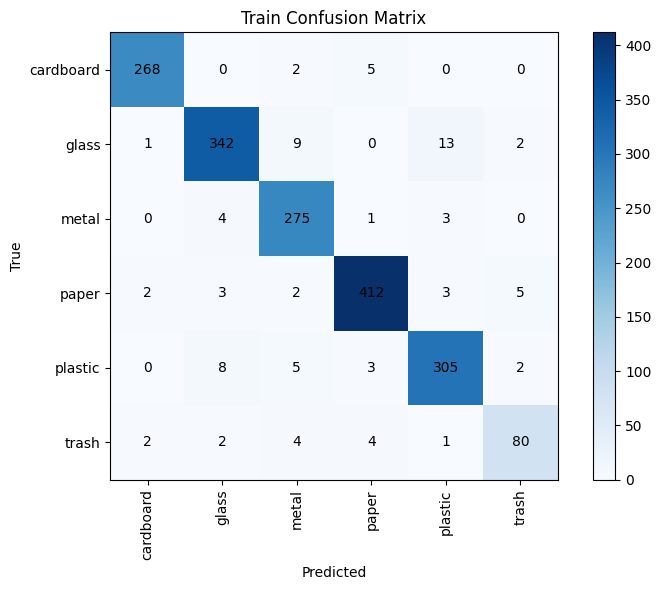


Validation Accuracy: 88.65%

Validation Classification Report:
              precision    recall  f1-score   support

   cardboard       0.91      0.93      0.92        68
       glass       0.86      0.89      0.88        71
       metal       0.80      0.89      0.84        63
       paper       0.95      0.93      0.94        84
     plastic       0.91      0.83      0.87        72
       trash       0.84      0.76      0.80        21

    accuracy                           0.89       379
   macro avg       0.88      0.87      0.87       379
weighted avg       0.89      0.89      0.89       379



In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ====================================================
#                 TRAIN EVALUATION
# ====================================================
model.eval()

all_preds_train = []
all_labels_train = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds_train.extend(preds)
        all_labels_train.extend(labels.cpu().numpy())

train_accuracy = (np.array(all_preds_train) == np.array(all_labels_train)).mean()
print(f"\nTrain Accuracy: {train_accuracy*100:.2f}%")

print("\nTrain Classification Report:")
print(classification_report(all_labels_train, all_preds_train, target_names=class_names))


# ========== TRAIN CONFUSION MATRIX ==========
cm_train = confusion_matrix(all_labels_train, all_preds_train)

plt.figure(figsize=(8,6))
plt.imshow(cm_train, cmap='Blues')
plt.title("Train Confusion Matrix")
plt.colorbar()

# angka di setiap kotak
num_classes = len(class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_train[i, j], ha='center', va='center', color='black')

plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# ====================================================
#                 VALIDATION EVALUATION
# ====================================================

all_preds_val = []
all_labels_val = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds_val.extend(preds)
        all_labels_val.extend(labels.cpu().numpy())

val_accuracy = (np.array(all_preds_val) == np.array(all_labels_val)).mean()
print(f"\nValidation Accuracy: {val_accuracy*100:.2f}%")

print("\nValidation Classification Report:")
print(classification_report(all_labels_val, all_preds_val, target_names=class_names))


In [31]:
# ============================
#  BEST CONFIG FROM TUNING
# ============================

best_dropout = 0.5
best_lr = 5e-5
best_weight_decay = 1e-4

print("=== Training Final Model 10 Epoch ===")
print(f"Dropout     : {best_dropout}")
print(f"LR          : {best_lr}")
print(f"WeightDecay : {best_weight_decay}")


# ============================
#  BUILD FINAL MODEL
# ============================

model_final = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
in_f = model_final.fc.in_features

model_final.fc = nn.Sequential(
    nn.Dropout(best_dropout),
    nn.Linear(in_f, num_classes)
)

model_final = model_final.to(device)


# ============================
# LOSS, OPTIMIZER, SCHEDULER
# ============================

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model_final.parameters(),
    lr=best_lr,
    weight_decay=best_weight_decay
)

scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


# ============================
# TRAIN FINAL MODEL (10 EPOCH)
# ============================

EPOCHS = 10
best_val_acc = 0
wait = 0
patience = 3

# SIMPAN LEARNING CURVE FINAL TRAINING
final_train_losses = []
final_val_losses = []
final_train_accs = []
final_val_accs = []

for epoch in range(EPOCHS):
    model_final.train()
    train_loss_sum = 0; train_correct = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_final(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_loader.dataset)
    train_loss = train_loss_sum / len(train_loader.dataset)

    # Simpan ke curve
    final_train_losses.append(train_loss)
    final_train_accs.append(train_acc)

    # ============================
    # VALIDATION
    # ============================

    model_final.eval()
    val_loss_sum = 0; val_correct = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_final(imgs)
            loss = criterion(out, labels)

            val_loss_sum += loss.item() * imgs.size(0)
            val_correct += (out.argmax(1) == labels).sum().item()

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    # Simpan ke curve
    final_val_losses.append(val_loss)
    final_val_accs.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_final.state_dict(), "best_final_model.pth")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("EARLY STOPPING TRIGGERED.")
            break

print(f"\nTraining selesai. Best Validation Accuracy = {best_val_acc:.4f}")



=== Training Final Model 10 Epoch ===
Dropout     : 0.5
LR          : 5e-05
WeightDecay : 0.0001
Epoch 1/10 | Train Acc: 0.5730 | Val Acc: 0.7942
Epoch 2/10 | Train Acc: 0.8235 | Val Acc: 0.8707
Epoch 3/10 | Train Acc: 0.8886 | Val Acc: 0.8813
Epoch 4/10 | Train Acc: 0.9253 | Val Acc: 0.9050
Epoch 5/10 | Train Acc: 0.9338 | Val Acc: 0.8892
Epoch 6/10 | Train Acc: 0.9570 | Val Acc: 0.8945
Epoch 7/10 | Train Acc: 0.9661 | Val Acc: 0.9208
Epoch 8/10 | Train Acc: 0.9649 | Val Acc: 0.9261
Epoch 9/10 | Train Acc: 0.9666 | Val Acc: 0.9314
Epoch 10/10 | Train Acc: 0.9808 | Val Acc: 0.9340

Training selesai. Best Validation Accuracy = 0.9340



--- Learning Curves (Final 10-Epoch Training) ---



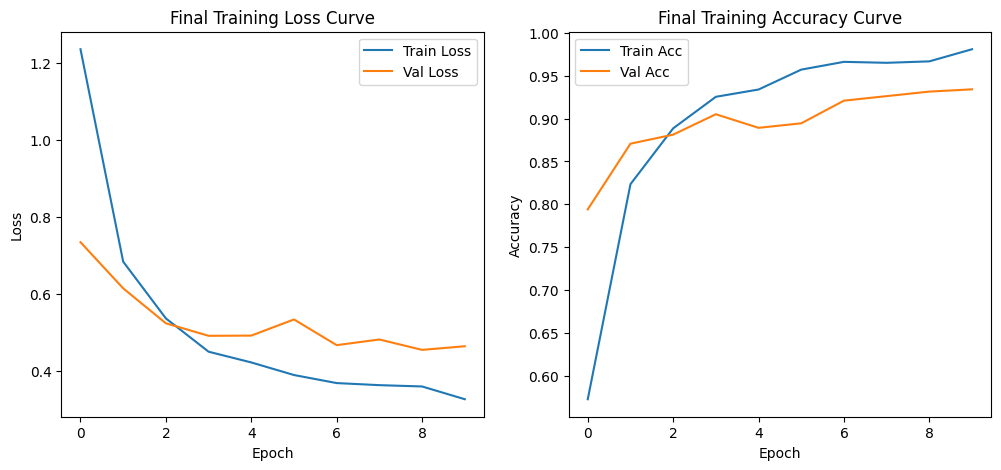

In [32]:
# ===============================================
#   VISUALISASI LEARNING CURVE FINAL TRAINING
# ===============================================
print("\n--- Learning Curves (Final 10-Epoch Training) ---\n")

plt.figure(figsize=(12,5))

# --- LOSS ---
plt.subplot(1,2,1)
plt.plot(final_train_losses, label='Train Loss')
plt.plot(final_val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Final Training Loss Curve")

# --- ACCURACY ---
plt.subplot(1,2,2)
plt.plot(final_train_accs, label='Train Acc')
plt.plot(final_val_accs, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Final Training Accuracy Curve")

plt.show()


In [75]:
print("\n--- Numerical Loss Values (Final 10-Epoch Training) ---\n")
print("Final Training Loss per Epoch:")
for i, loss in enumerate(final_train_losses):
    print(f"- Epoch {i+1}: {loss:.2f}")

print("\nFinal Validation Loss per Epoch:")
for i, loss in enumerate(final_val_losses):
    print(f"- Epoch {i+1}: {loss:.2f}")


--- Numerical Loss Values (Final 10-Epoch Training) ---

Final Training Loss per Epoch:
- Epoch 1: 1.23
- Epoch 2: 0.68
- Epoch 3: 0.54
- Epoch 4: 0.45
- Epoch 5: 0.42
- Epoch 6: 0.39
- Epoch 7: 0.37
- Epoch 8: 0.36
- Epoch 9: 0.36
- Epoch 10: 0.33

Final Validation Loss per Epoch:
- Epoch 1: 0.73
- Epoch 2: 0.61
- Epoch 3: 0.52
- Epoch 4: 0.49
- Epoch 5: 0.49
- Epoch 6: 0.53
- Epoch 7: 0.47
- Epoch 8: 0.48
- Epoch 9: 0.45
- Epoch 10: 0.46



Test Accuracy: 91.58%

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.98      0.88      0.93        60
       glass       0.86      0.97      0.91        63
       metal       0.95      0.91      0.93        64
       paper       0.88      0.99      0.93        83
     plastic       0.94      0.90      0.92        87
       trash       0.89      0.70      0.78        23

    accuracy                           0.92       380
   macro avg       0.92      0.89      0.90       380
weighted avg       0.92      0.92      0.91       380



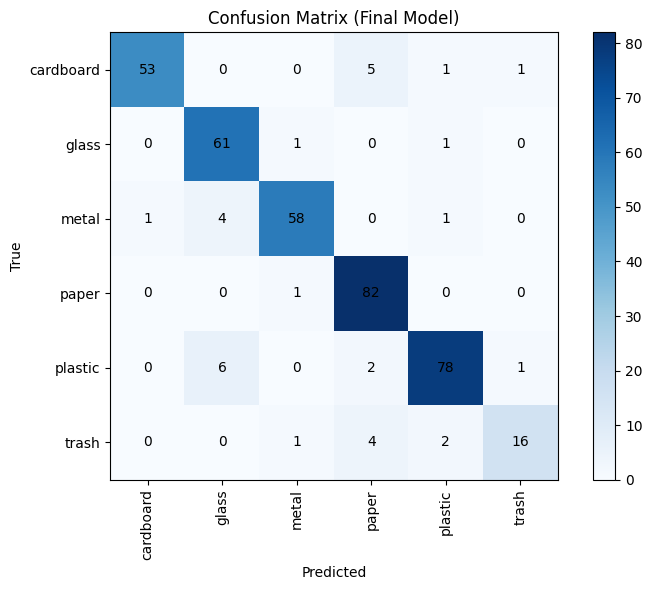

In [33]:
model_final.load_state_dict(torch.load("best_final_model.pth"))
model_final.eval()

all_preds_final = []
all_labels_final = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_final(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds_final.extend(preds)
        all_labels_final.extend(labels.numpy())

test_accuracy_final = (np.array(all_preds_final) == np.array(all_labels_final)).mean()
print(f"\nTest Accuracy: {test_accuracy_final*100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels_final, all_preds_final, target_names=class_names))

cm_final = confusion_matrix(all_labels_final, all_preds_final)

plt.figure(figsize=(8,6))
plt.imshow(cm_final, cmap='Blues')
plt.title("Confusion Matrix (Final Model)")
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_final[i, j], ha='center', va='center', color='black')

plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [66]:
import torch
import torch.nn.functional as F

def predict_image(path):
    img = Image.open(path).convert("RGB")
    tf = val_tf  # gunakan transform validasi/testing
    x = tf(img).unsqueeze(0).to(device)

    model_final.eval()

    with torch.no_grad():
        out = model_final(x)
        probs = F.softmax(out, dim=1)
        conf, pred = torch.max(probs, dim=1)

    predicted_class = class_names[pred.item()]
    confidence_percent = conf.item() * 100       # ubah ke persen

    # Tampilkan gambar + prediksi
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence_percent:.2f}%)")
    plt.axis('off')
    plt.show()

    # OPTIONAL: tampilkan semua probabilitas per kelas
    print("\nProbabilitas per Kelas:")
    for i, cls in enumerate(class_names):
        print(f"{cls:10s} : {probs[0][i].item()*100:.2f}%")




In [61]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(path):
    img = Image.open(path).convert("RGB")

    # Gunakan transform validasi
    x = val_tf(img).unsqueeze(0).to(device)

    model_final.eval()

    with torch.no_grad():
        out = model_final(x)                # <<< perbaikan: gunakan model_final
        probs = F.softmax(out, dim=1)[0]    # probabilitas softmax
        pred = torch.argmax(probs).item()   # ambil index prediksi
        confidence = probs[pred].item() * 100

    # Tampilkan gambar + prediksi
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print("\nProbabilitas per kelas:")
    for i, cls in enumerate(class_names):
        print(f"{cls:10s} : {probs[i].item()*100:.2f}%")


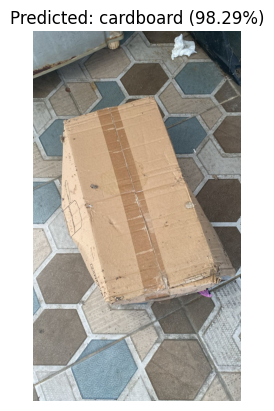


Probabilitas per Kelas:
cardboard  : 98.29%
glass      : 0.07%
metal      : 0.30%
paper      : 0.51%
plastic    : 0.36%
trash      : 0.47%


In [67]:
predict_image("/content/test2.jpg")


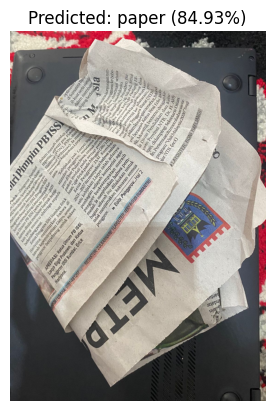


Probabilitas per kelas:
cardboard  : 8.70%
glass      : 0.15%
metal      : 0.91%
paper      : 84.93%
plastic    : 2.31%
trash      : 3.00%


In [64]:
predict_image("/content/2.jpg")

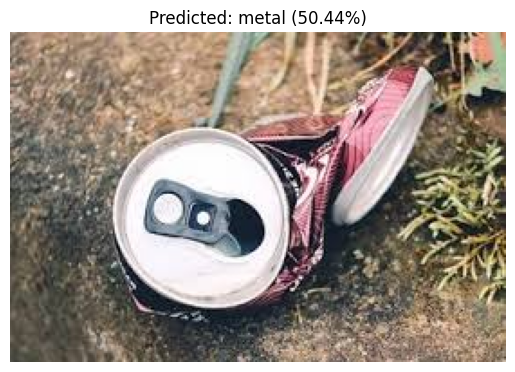


Probabilitas per kelas:
cardboard  : 3.50%
glass      : 0.83%
metal      : 50.44%
paper      : 39.50%
plastic    : 4.47%
trash      : 1.26%


In [65]:
predict_image("/content/metal.jpeg")

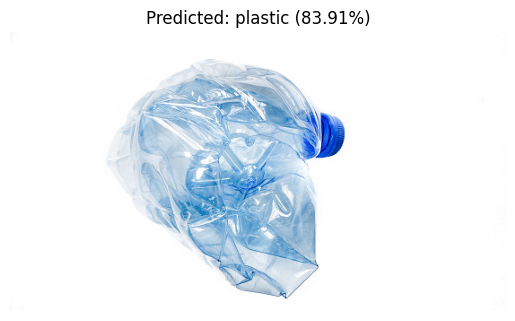


Probabilitas per Kelas:
cardboard  : 1.05%
glass      : 0.82%
metal      : 3.70%
paper      : 9.16%
plastic    : 83.91%
trash      : 1.37%


In [71]:
predict_image("/content/6.jpg")

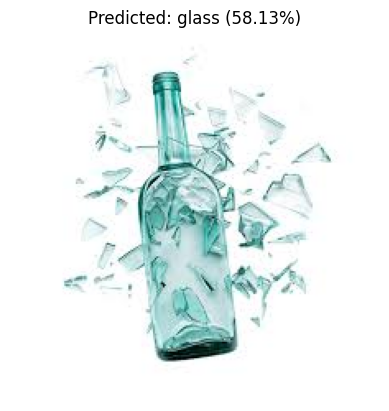


Probabilitas per Kelas:
cardboard  : 12.17%
glass      : 58.13%
metal      : 1.46%
paper      : 14.60%
plastic    : 12.03%
trash      : 1.60%


In [74]:
predict_image("/content/7.jpeg")